In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AI python/projects/my tasks github/paster_project/advanced_paster_haccp_data.csv")

In [ ]:
df.head()

,Timestamp,Inlet_Temp,Heating_Section_Temp,Holding_Tube_Temp,Outlet_Temp,Flow_Rate_LPH,Differential_Pressure,Milk_Conductivity,pH_Level,Pump_Speed_RPM,Valve_Position_Pct,Pasteurization_Time_Sec
0,2026-01-15 09:38:45.430432,4.248357,73.797447,72.327301,3.885919,4998.348737,0.466075,4.617481,6.638788,1467.586146,85.643670,16.005286
1,2026-01-15 09:39:45.430432,3.930868,73.956644,72.493759,4.369069,4974.817487,0.484725,4.312102,6.639458,1450.786184,83.437285,16.080992
2,2026-01-15 09:40:45.430432,4.323844,73.762274,72.503603,4.057940,4991.381252,0.470131,4.467220,6.761771,1431.753490,86.382713,16.027628
3,2026-01-15 09:41:45.430432,4.761515,73.907612,72.594526,4.452004,5035.736586,0.505521,4.495834,6.690466,1440.750017,83.819277,15.886454
4,2026-01-15 09:42:45.430432,3.882923,73.431916,72.226628,4.785850,5063.892833,0.559859,4.501591,6.774033,1456.857069,86.499110,15.798123


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                2000 non-null   object 
 1   Inlet_Temp               2000 non-null   float64
 2   Heating_Section_Temp     2000 non-null   float64
 3   Holding_Tube_Temp        2000 non-null   float64
 4   Outlet_Temp              2000 non-null   float64
 5   Flow_Rate_LPH            2000 non-null   float64
 6   Differential_Pressure    2000 non-null   float64
 7   Milk_Conductivity        2000 non-null   float64
 8   pH_Level                 2000 non-null   float64
 9   Pump_Speed_RPM           2000 non-null   float64
 10  Valve_Position_Pct       2000 non-null   float64
 11  Pasteurization_Time_Sec  2000 non-null   float64
dtypes: float64(11), object(1)
memory usage: 187.6+ KB


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [ ]:
df.describe()

,Timestamp,Inlet_Temp,Heating_Section_Temp,Holding_Tube_Temp,Outlet_Temp,Flow_Rate_LPH,Differential_Pressure,Milk_Conductivity,pH_Level,Pump_Speed_RPM,Valve_Position_Pct,Pasteurization_Time_Sec
count,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2026-01-16 02:18:15.430432256,4.022542,73.998067,72.479283,4.995530,5006.444506,0.495327,4.503635,6.650599,1454.443172,85.282984,15.983099
min,2026-01-15 09:38:45.430432,2.379366,73.094146,70.406551,1.311635,4803.879987,0.046556,4.191744,6.468240,1390.094662,77.287249,14.118316
25%,2026-01-15 17:58:30.430432,3.688669,73.787262,72.358342,4.274669,4968.254133,0.465423,4.436362,6.616609,1437.435936,83.708048,15.890807
50%,2026-01-16 02:18:15.430432,4.022346,73.999984,72.492336,4.969475,5001.033595,0.497182,4.505147,6.649944,1451.376983,85.066034,15.996693
75%,2026-01-16 10:38:00.430432,4.341489,74.199663,72.625292,5.710375,5034.357274,0.530840,4.570141,6.684802,1465.855601,86.517324,16.102236
max,2026-01-16 18:57:45.430432,5.926366,75.177871,73.122582,8.529055,5666.398338,0.668888,4.842891,6.873954,1626.764993,99.784597,16.653205
std,NaN,0.494233,0.301606,0.247516,1.033419,78.636855,0.061263,0.099987,0.050758,30.459764,2.593390,0.235762


**مصفوفة الارتباط (Correlation Heatmap)**

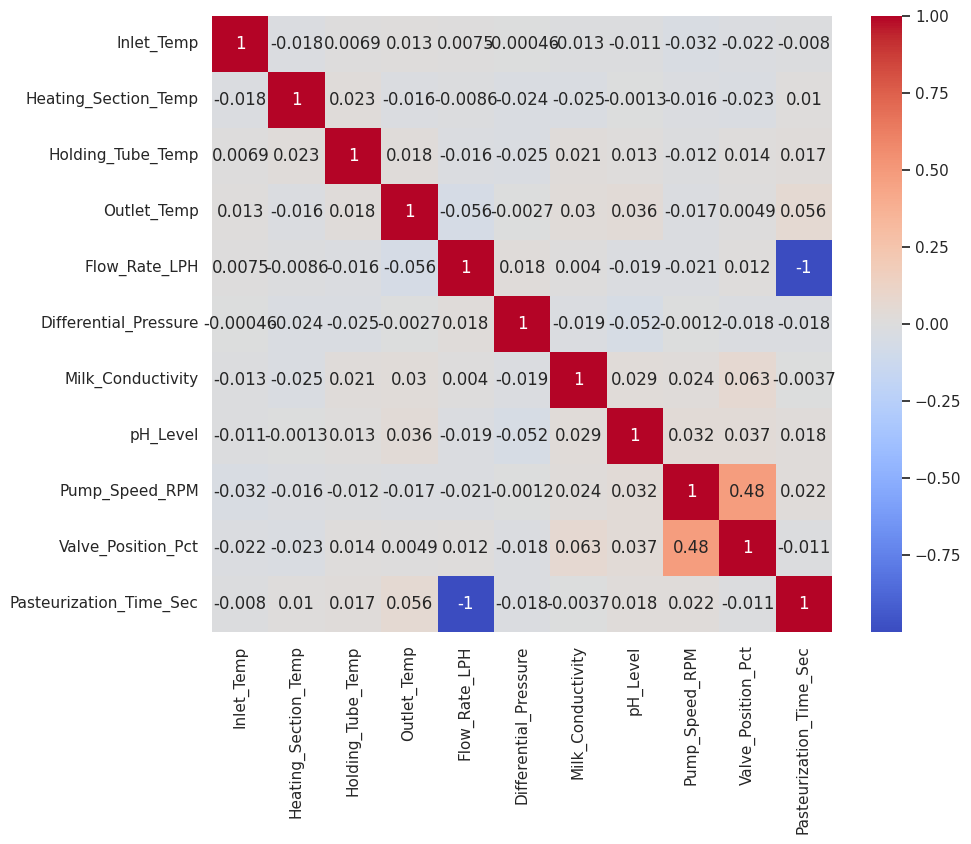

In [ ]:
plt.figure(figsize=(10, 8))
# حساب الارتباط بين الاعمدة الرقمية فقط
corr = df.drop("Timestamp", axis = 1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


**توزيع زمن البسترة مع خط CCP  نقطة الضبط الحرج (Distribution Plot)**

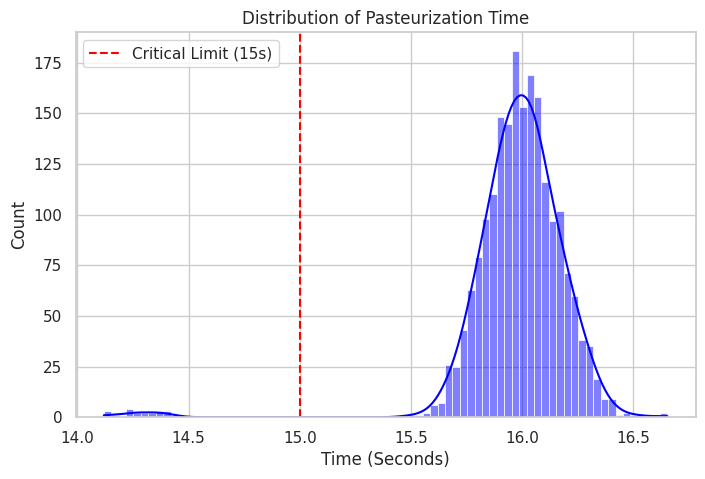

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Pasteurization_Time_Sec'], kde=True, color='blue')
# إضافة خط أحمر عند الحد القانوني (15 ثانية)
plt.axvline(x=15, color='red', linestyle='--', label='Critical Limit (15s)')
plt.title('Distribution of Pasteurization Time')
plt.xlabel('Time (Seconds)')
plt.legend()
plt.show()

**مخطط التشتت الذكي (Temp vs Time vs Flow)**

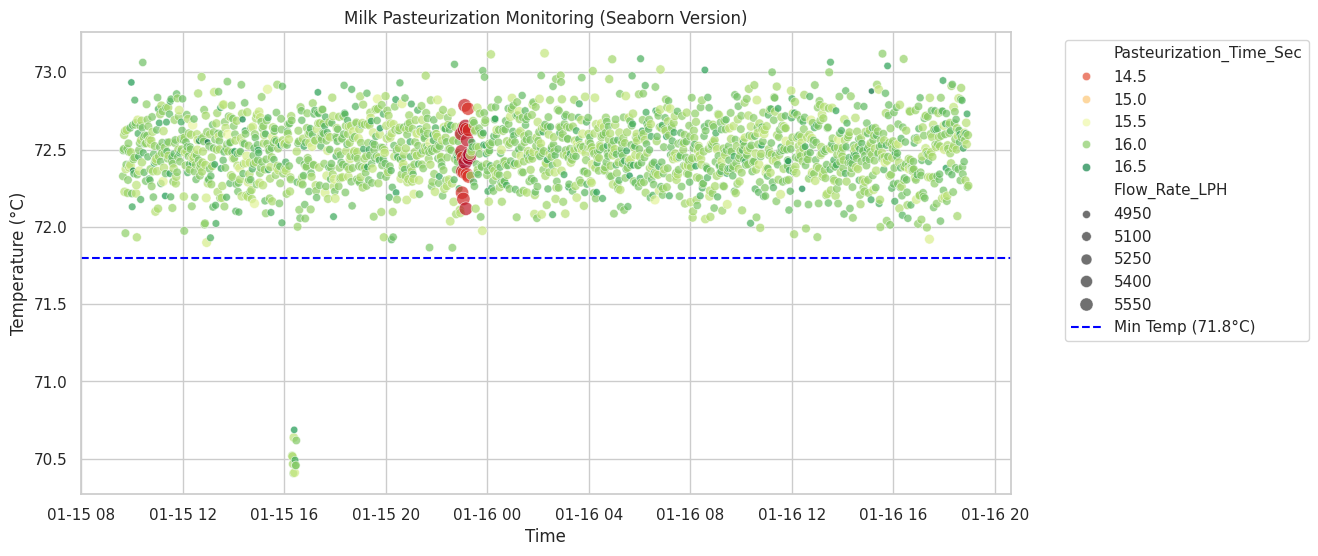

In [ ]:

# ضبط نمط الرسم ليكون أكثر احترافية (خلفية شبكية)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

scatter = sns.scatterplot(
    data=df,
    x='Timestamp',
    y='Holding_Tube_Temp',
    hue='Pasteurization_Time_Sec', # ربط اللون بزمن البسترة
    palette='RdYlGn',              # تدرج الألوان من الأحمر للأخضر
    size='Flow_Rate_LPH',          # ربط حجم النقطة بمعدل التدفق
    sizes=(20, 100),               # تحديد نطاق أحجام النقاط
    alpha=0.7                      # شفافية بسيطة لرؤية النقاط المتداخلة
)

# إضافة الخط الحرج (القيمة القانونية للبسترة)
plt.axhline(y=71.8, color='blue', linestyle='--', label='Min Temp (71.8°C)')

plt.title('Milk Pasteurization Monitoring (Seaborn Version)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

**رسم السلاسل الزمنية للمستشعرات (Time Series Multi-plot)**

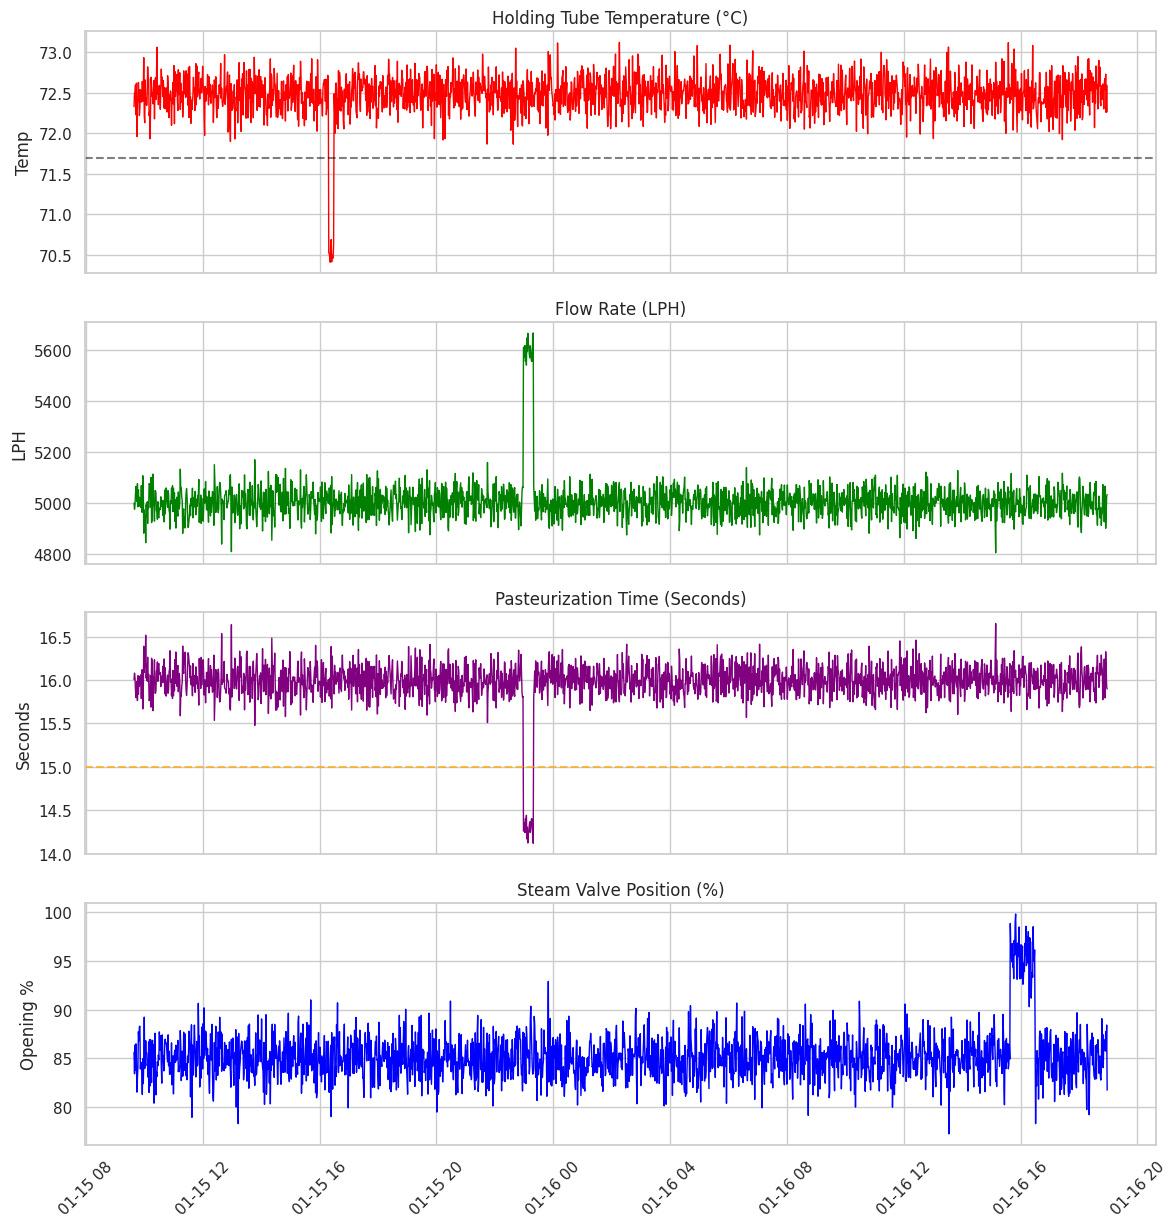

In [ ]:

# إنشاء 4 مخططات عمودية تشترك في نفس المحور الأفقي (الوقت)
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# 1. رسم الحرارة (Holding Tube Temperature)
axes[0].plot(df['Timestamp'], df['Holding_Tube_Temp'], color='red', linewidth=1)
axes[0].axhline(y=71.8, color='black', linestyle='--', alpha=0.5) # خط الحد الأدنى
axes[0].set_title('Holding Tube Temperature (°C)')
axes[0].set_ylabel('Temp')

# 2. رسم التدفق (Flow Rate)
axes[1].plot(df['Timestamp'], df['Flow_Rate_LPH'], color='green', linewidth=1)
axes[1].set_title('Flow Rate (LPH)')
axes[1].set_ylabel('LPH')

# 3. رسم زمن البسترة (Pasteurization Time) - المخطط الجديد
axes[2].plot(df['Timestamp'], df['Pasteurization_Time_Sec'], color='purple', linewidth=1)
axes[2].axhline(y=15, color='orange', linestyle='--', alpha=0.7) # خط الـ 15 ثانية
axes[2].set_title('Pasteurization Time (Seconds)')
axes[2].set_ylabel('Seconds')

# 4. رسم وضعية الصمام (Steam Valve Position)
axes[3].plot(df['Timestamp'], df['Valve_Position_Pct'], color='blue', linewidth=1)
axes[3].set_title('Steam Valve Position (%)')
axes[3].set_ylabel('Opening %')



plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

**Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
import shap

In [ ]:
scl = StandardScaler()
num_df = df.drop("Timestamp", axis = 1)
num_df_array = scl.fit_transform(num_df)
new_df = pd.DataFrame(num_df_array, columns=num_df.columns)
new_df.head()

,Inlet_Temp,Heating_Section_Temp,Holding_Tube_Temp,Outlet_Temp,Flow_Rate_LPH,Differential_Pressure,Milk_Conductivity,pH_Level,Pump_Speed_RPM,Valve_Position_Pct,Pasteurization_Time_Sec
0,0.457014,-0.665341,-0.614181,-1.073997,-0.102977,-0.477589,1.138895,-0.232743,0.431594,0.139114,0.094129
1,-0.185534,-0.137375,0.058503,-0.606354,-0.402291,-0.173092,-1.916056,-0.219533,-0.120090,-0.711872,0.415322
2,0.609789,-0.781987,0.098284,-0.907497,-0.191603,-0.411371,-0.364283,2.190799,-0.745093,0.424157,0.188917
3,1.495566,-0.299988,0.465717,-0.526081,0.372591,0.166444,-0.078039,0.785629,-0.449661,-0.564540,-0.410028
4,-0.282567,-1.877591,-1.021016,-0.202951,0.730735,1.053627,-0.020449,2.432421,0.079269,0.469050,-0.784787


In [ ]:
x = new_df.copy()
model = IsolationForest(contamination=0.03,random_state=42,max_samples='auto',n_estimators=200)
new_df['Anomaly_Score'] =  model.fit_predict(x) # انشاء عمود لنتائج الكشف عن الانحرافات


**Scor & Evaluation**

In [ ]:
# 1. استخراج التسميات (Labels) التي نتجت عن النموذج
labels = new_df['Anomaly_Score']

# 2. نستخدم الخوارزمية مع الداتا قبل التنبؤ و عمود التنبؤ او التارغت المتنبأ بها
score = silhouette_score(x, labels)

print(f"Silhouette Score: {score:.2f}")

Silhouette Score: 0.53


النتيجة اكبر من 0.5 فالنموذج تقييمه مرتفع وممثل

In [ ]:
new_df['Scores'] = model.decision_function(x) # عرض درجة الغرابة او درجة الانحراف عن القيم الطبيعية
new_df['Timestamp']=df['Timestamp']
print(new_df[['Timestamp', 'Scores']].sort_values(by='Scores').head()) #عرض أكثر النقاط غرابة بناءً على الدرجة الرقمية
#ml_df = ml_df.reset_index(drop=True)


                      Timestamp    Scores
1808 2026-01-16 15:46:45.430432 -0.095088
820  2026-01-15 23:18:45.430432 -0.079140
819  2026-01-15 23:17:45.430432 -0.068372
814  2026-01-15 23:12:45.430432 -0.058658
805  2026-01-15 23:03:45.430432 -0.056652


**Predictive Analysis**

In [ ]:
# حساب قيم SHAP وتفسير الأسباب
exp = shap.TreeExplainer(model) # بناء الاوبجكت
result_values = exp.shap_values(x)


In [ ]:
# استخراج "مزيج الأسباب" (Top 3 Reasons)
anomaly_indices = new_df[new_df['Anomaly_Score'] == -1].index


In [ ]:
analysis_results = []

for a in anomaly_indices:
    row_shap = result_values[a]

    # الحصول على أندكس أعلى 3 ميزات
    top_3_idx = np.argsort(row_shap)[-3:][::-1]

    # حساب الإجمالي للميزات الموجبة
    total_impact = np.sum(row_shap[row_shap > 0])

    # إنشاء قائمة الأسباب مع استخدام تنسيق :.1f

    causes = [
        f"{x.columns[i]} ({(row_shap[i]/total_impact)*100: .1f}%)"
        if total_impact > 0 else f"{x.columns[i]} (0%)"
        for i in top_3_idx
    ]


    # تخزين كل سبب في حقل منفصل (لوحده)
    analysis_results.append({
        'Timestamp': new_df.iloc[a]['Timestamp'],
        'Primary_Cause': causes[0],
        'Secondary_Cause': causes[1],
        'Tertiary_Cause': causes[2]
    })

# تحويل النتائج إلى DataFrame لسهولة العرض
import pandas as pd
final_analysis_df = pd.DataFrame(analysis_results)

In [ ]:
results_df = pd.DataFrame(analysis_results)
pd.set_option('display.max_colwidth', None)
print(results_df)

# حفظ الملف
results_df.to_csv('HACCP_Pasterzution_Analysis.csv', index=False)


                    Timestamp                   Primary_Cause  \
0  2026-01-15 16:22:45.430432  Differential_Pressure ( 23.2%)   
1  2026-01-15 16:23:45.430432      Milk_Conductivity ( 41.8%)   
2  2026-01-15 16:24:45.430432            Outlet_Temp ( 46.7%)   
3  2026-01-15 22:58:45.430432               pH_Level ( 25.5%)   
4  2026-01-15 22:59:45.430432         Pump_Speed_RPM ( 26.2%)   
5  2026-01-15 23:00:45.430432   Heating_Section_Temp ( 23.8%)   
6  2026-01-15 23:01:45.430432               pH_Level ( 27.6%)   
7  2026-01-15 23:03:45.430432            Outlet_Temp ( 31.5%)   
8  2026-01-15 23:04:45.430432               pH_Level ( 23.5%)   
9  2026-01-15 23:05:45.430432      Milk_Conductivity ( 26.8%)   
10 2026-01-15 23:06:45.430432      Milk_Conductivity ( 23.0%)   
11 2026-01-15 23:07:45.430432      Milk_Conductivity ( 22.1%)   
12 2026-01-15 23:08:45.430432         Pump_Speed_RPM ( 20.9%)   
13 2026-01-15 23:09:45.430432  Differential_Pressure ( 24.6%)   
14 2026-01-15 23:10:45.43